In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
quick_test = False

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle
from scipy.interpolate import interp1d
import pandas as pd
import sncosmo
from scipy import stats
from scipy.special import expit
from nested_pandas import read_parquet
from joblib import Parallel, delayed
import cloudpickle as pickle
from regions import RectangleSkyRegion
from astropy.coordinates import SkyCoord
import astropy.units as u

from lightcurvelynx.obstable.ztf_obstable import ZTFObsTable
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.pzflow_node import PZFlowNode
from lightcurvelynx.astro_utils.snia_utils import (
    DistModFromRedshift,
    HostmassX1Func,
    X0FromDistMod,
    num_snia_per_redshift_bin,
    SNCoordGivenPhysicalSep,
)
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.models.sncomso_models import SncosmoWrapperModel
from lightcurvelynx.models.snia_host import SNIaHost
from lightcurvelynx.utils.plotting import plot_lightcurves
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableUniformRADECSampler
from lightcurvelynx.astro_utils.dustmap import DustmapWrapper,SFDMap
from lightcurvelynx.effects.extinction import ExtinctionEffect
from lightcurvelynx.astro_utils.mag_flux import mag2flux,flux2mag
from lightcurvelynx.astro_utils.detector_footprint import DetectorFootprint

from lightcurvelynx import _LIGHTCURVELYNX_BASE_DATA_DIR

from lightcurvelynx.validation.lcfit import fit_single_lc

In [4]:
globalhostdata = pd.read_csv('ztfsniadr2/tables/globalhost_data.csv')
localhostdata = pd.read_csv('ztfsniadr2/tables/localhost_data.csv')
sndata = pd.read_csv('ztfsniadr2/tables/snia_data.csv')
data = pd.merge(sndata,globalhostdata,on='ztfname')

In [5]:
lcdata = read_parquet('data/ztfsniadr2.parquet')

In [6]:
%%time

obs_log = pd.read_parquet('data/ztf_observing_log_combined_w_metadata.parquet')
colmap = {"ra":"ra",
          "dec":"dec",
          "time":"mjd",
          "zp":"zp_nJy",
          "filter":"filter",
          "sky":"scibckgnd",
         }

#ztf ccd size 6144 × 6160 pixel * 16
pixel_scale = 1.01 #arcsec/pixel
center = SkyCoord(ra=0.0, dec=0.0, unit="deg", frame="icrs")
rect_region = RectangleSkyRegion(center=center, width=6144.* pixel_scale * u.arcsec, 
                                 height=6160.* pixel_scale * u.arcsec, angle=0.0 * u.deg)
ztf_fp = DetectorFootprint(rect_region, pixel_scale=pixel_scale)

ztf_obstable = ZTFObsTable(obs_log,colmap=colmap)#,detector_footprint=ztf_fp)
# ztf_obstable.radius = 3.868

t_min, t_max = ztf_obstable.time_bounds()
print(f"Loaded OpSim with {len(ztf_obstable)} rows and times [{t_min}, {t_max}]")

passband_group = PassbandGroup.from_preset(preset="ZTF", filters=["g", "r", "i"])
print(f"Loaded Passbands: {passband_group}")

2025-10-01 10:08:49,777 - INFO - Loading passbands from preset ZTF


Loaded OpSim with 520115 rows and times [58288.171875, 59273.5546875]
Loaded Passbands: PassbandGroup containing 3 passbands: ZTF_g, ZTF_r, ZTF_i
CPU times: user 482 ms, sys: 76.1 ms, total: 559 ms
Wall time: 507 ms


In [7]:
# Load the Flow model into a PZFlow node. This gives access to all of the outputs of the
# flow model as attributes of the PZFlowNode.
pz_node = PZFlowNode.from_file("data/ztfsniadr2_host_sn_before_selection_pzflow.pkl",  # filename
    node_label="pznode",
)
radec_node = ObsTableUniformRADECSampler(ztf_obstable, radius=ztf_obstable.radius, node_label="radec")

# Create a model for the host of the SNIa. The attributes will be sampled via
# the PZFlowNode's model. So each hos instantiation will have its own properties.
# Note: This requires the user to know the output names from the underlying flow model.

zmin = 0.001
zmax = 0.2
H0 = 70.0
Omega_m = 0.3
nsn, z = num_snia_per_redshift_bin(zmin, zmax, 100, H0=H0, Omega_m=Omega_m)
zpdf = interp1d(z, nsn, bounds_error=False, fill_value=0)

host = SNIaHost(
    ra = radec_node.ra,
    dec = radec_node.dec,
    hostmass=pz_node.mass,
    redshift=SamplePDF(zpdf),
    node_label="host",
)

INFO:2025-10-01 10:08:50,045:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-10-01 10:08:50,045 - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2025-10-01 10:08:50,046:jax._src.xla_bridge:927: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/mi/anaconda3/envs/lightcurvelynx/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)
2025-10-01 10:08:50,046 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboo

In [8]:
distmod_func = DistModFromRedshift(host.redshift, H0=H0, Omega_m=Omega_m)

m_abs_func = NumpyRandomFunc("normal", loc=-19.05, scale=0.1)

# we model host-sn separation as an exponential distribution based on Fig 3 of Gupta et al 2016, mean separation = 5kpc
physical_host_sn_sep = NumpyRandomFunc("exponential", scale = 5.)
sncoor_node = SNCoordGivenPhysicalSep(host.ra, host.dec, physical_host_sn_sep, host.redshift, H0=H0, Omega_m=Omega_m,node_label='sncoor_node')

x0_func = X0FromDistMod(
    distmod=distmod_func,
    x1=pz_node.x1,
    c=pz_node.c,
    alpha=0.14,
    beta=3.1,
    m_abs=m_abs_func,
    node_label="x0_func",
)

sncosmo_modelname = "salt3"
source = SncosmoWrapperModel(
    sncosmo_modelname,
    t0=NumpyRandomFunc("uniform", low=t_min, high=t_max),
    x0=x0_func,
    x1=pz_node.x1,
    c=pz_node.c,
    ra=sncoor_node.ra,
    dec=sncoor_node.dec,
    redshift=host.redshift,
    node_label="source",
)
    
mwextinction = SFDMap(
    ra=source.ra,
    dec=source.dec,
    node_label="mwext",
)

# Create an extinction effect using the EBVs from that dust map.
ext_effect = ExtinctionEffect(extinction_model="F99", frame='observer', ebv=mwextinction, Rv=3.1)
source.add_effect(ext_effect)


2025-10-01 10:08:51,240 - INFO - SFD dust map data files not found.
Attempting to download from: ('https://github.com/kbarbary/sfddata/archive/master.tar.gz',)
to the directory /Users/mi/Work/lightcurvelynx/lightcurvelynx/data/dustmaps/sfdmap2


In [9]:
# save model and passbands to pickles
data_to_save = (source, passband_group)
with open("results/saved_model_and_passband.pkl", "wb") as file:
    pickle.dump(data_to_save, file)

In [10]:
### Notes:
### ZTF SN Ia DR2 dates: March(April 1) 2018 - December (Dec 31) 2020
### ZTF has square field?
### Data release has 3628 SN Ia in total
### 2667 passed data quality cut
### volume-limited complete sample to z<0.06

In [11]:
%%time
if quick_test:
    nsntotal = 3000
else:
    survey_length = (t_max - t_min)/365.
    nsntotal, _ = num_snia_per_redshift_bin(zmin, zmax, 1, H0=H0, Omega_m=Omega_m, solid_angle=9.136*survey_length)
    print(f"Survey length = {survey_length} years")
print(f"Simulating {int(nsntotal)} SN ...")
lightcurves = simulate_lightcurves(source, int(nsntotal), ztf_obstable, passband_group)
lightcurves

Survey length = 2.6996789383561643 years
Simulating 128768 SN ...


<timed exec>:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
<timed exec>:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)


CPU times: user 8min 57s, sys: 1min 23s, total: 10min 20s
Wall time: 10min 22s


id          ra        dec  nobs            t0         z  \
0            0  199.481034  41.838571  1105  59074.599915  0.156601   
1            1   59.985667 -15.129433   657  58487.141962  0.136212   
...        ...         ...        ...   ...           ...       ...   
128766  128766  118.503443 -13.808141    48  58587.797518  0.158612   
128767  128767   48.773692 -15.786496   568  58872.953240  0.198680   

                                                   params  \
0       {'radec.ra': 199.48144850677525, 'radec.dec': ...   
1       {'radec.ra': 59.985084071131986, 'radec.dec': ...   
...                                                   ...   
128766  {'radec.ra': 118.50324741581859, 'radec.dec': ...   
128767  {'radec.ra': 48.77361293980133, 'radec.dec': -...   

                                               lightcurve  
0       [{mjd: 58288.222656, filter: 'g', flux: -2528....  
1       [{mjd: 58335.5, filter: 'g', flux: -452.064582...  
...                                                   ...  
128766  [{mjd: 58439.378906, filter: 'r', flux: -1714....  
128767  [{mjd: 58331.480469, filter: 'g', flux: -2174....  

[128768 rows x 8 columns]

In [12]:
lightcurves['params'][0].keys()

dict_keys(['radec.ra', 'radec.dec', 'host.ra', 'host.dec', 'host.redshift', 'host.t0', 'host.distance', 'host.hostmass', 'SamplePDF:_rvs_4.function_node_result', 'pznode.mass', 'pznode.x1', 'pznode.c', 'sncoor_node.host_ra', 'sncoor_node.host_dec', 'sncoor_node.physical_sep_kpc', 'sncoor_node.redshift', 'sncoor_node.ra', 'sncoor_node.dec', 'NumpyRandomFunc:exponential_6.scale', 'NumpyRandomFunc:exponential_6.function_node_result', 'source.ra', 'source.dec', 'source.redshift', 'source.t0', 'source.distance', 'source.x0', 'source.x1', 'source.c', 'source.Rv', 'source.ebv', 'NumpyRandomFunc:uniform_7.low', 'NumpyRandomFunc:uniform_7.high', 'NumpyRandomFunc:uniform_7.function_node_result', 'DistModFromRedshift:_distmod_from_redshift_9.redshift', 'DistModFromRedshift:_distmod_from_redshift_9.function_node_result', 'x0_func.distmod', 'x0_func.x1', 'x0_func.c', 'x0_func.alpha', 'x0_func.beta', 'x0_func.m_abs', 'x0_func.function_node_result', 'NumpyRandomFunc:normal_10.loc', 'NumpyRandomFunc:n

In [13]:
lightcurves.lightcurve.isna().sum()

np.int64(14)

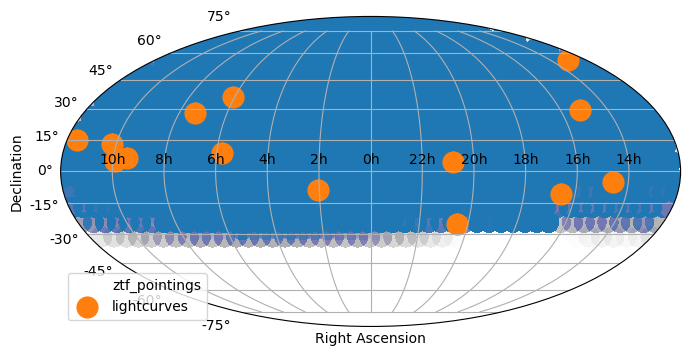

In [14]:
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection='mollweide')

# Convert RA/Dec (deg) to Mollweide coords (radians)
ra_rad = np.radians(ztf_obstable._table.ra)
dec_rad = np.radians(ztf_obstable._table.dec)

# Shift RA: matplotlib Mollweide expects longitude from -π to +π
ra_moll = np.remainder(ra_rad + 2*np.pi, 2*np.pi)
ra_moll[ra_moll > np.pi] -= 2*np.pi
ra_moll = -ra_moll  # reverse RA (to match astronomy convention)

# convert (quick) : 1 deg on x-axis spans total width of 2π rad = 360 deg
# axis width in points:
r_deg = 3.89
bbox = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
width_in = bbox.width
width_pt = width_in * fig.dpi * 72/72  # matplotlib already uses points; still compute for clarity
# diameter in degrees -> as fraction of 360°
diam_deg = 2*r_deg
frac = diam_deg / 360.0
# axis width in points (approx for marker size)
axis_width_pts = fig.get_figwidth()*fig.dpi  # rough
diam_pts = frac * axis_width_pts
s = (diam_pts/2)**2 * np.pi  # area in points^2 for a circle marker

# Plot
ax.scatter(ra_moll, dec_rad, s=s, alpha=0.005, edgecolors="none",label='ztf_pointings')

ra_rad = np.radians(lightcurves.ra)
dec_rad = np.radians(lightcurves.dec)

ra_moll = np.remainder(ra_rad + 2*np.pi, 2*np.pi)
ra_moll[ra_moll > np.pi] -= 2*np.pi
ra_moll = -ra_moll  # reverse RA (to match astronomy convention)

# ax.scatter(ra_moll, dec_rad, marker='.', alpha=0.005,label='lightcurves')

idx = lightcurves.lightcurve.isna()
ra_rad = np.radians(lightcurves.loc[idx].ra)
dec_rad = np.radians(lightcurves.loc[idx].dec)

ra_moll = np.remainder(ra_rad + 2*np.pi, 2*np.pi)
ra_moll[ra_moll > np.pi] -= 2*np.pi
ra_moll = -ra_moll  # reverse RA (to match astronomy convention)

ax.scatter(ra_moll, dec_rad, marker='o', alpha=1, lw=10, label='lightcurves')

# Set RA ticks (in hours)
ra_tick_labels = np.array([150, 120, 90, 60, 30, 0, 330, 300, 270, 240, 210])
ax.set_xticks(np.radians(np.linspace(-150, 150, len(ra_tick_labels))))
ax.set_xticklabels([f"{int(x/15)}h" for x in ra_tick_labels])  # RA in hours

# Set Dec ticks (default is fine, but make sure labeled in degrees)
ax.set_yticks(np.radians(np.arange(-75, 90, 15)))
ax.set_yticklabels([f"{d}°" for d in np.arange(-75, 90, 15)])

# Axis labels
ax.set_xlabel("Right Ascension")
ax.set_ylabel("Declination")

ax.grid(True)
plt.legend()
plt.show()

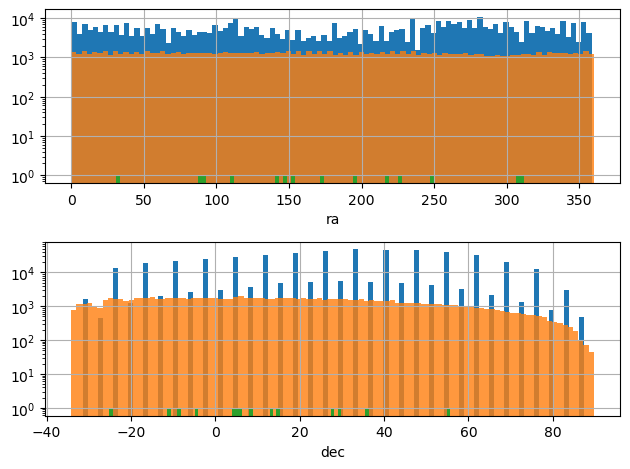

In [15]:
idx = lightcurves.lightcurve.isna()

plt.subplot(2,1,1)
ztf_obstable._table.ra.hist(bins=100,density=False)
lightcurves.ra.hist(bins=100,alpha=0.8,density=False)
lightcurves.loc[idx].ra.hist(bins=100)
plt.yscale('log')
plt.xlabel('ra')

plt.subplot(2,1,2)
ztf_obstable._table.dec.hist(bins=100,density=False)
lightcurves.dec.hist(bins=100,alpha=0.8,density=False)
lightcurves.loc[idx].dec.hist(bins=100)
plt.yscale('log')
plt.xlabel('dec')

plt.tight_layout()

In [16]:
# calculate detection flag
lightcurves = lightcurves.dropna(subset=['lightcurve'])
print("Before applying detection: nsn=", len(lightcurves))
lightcurves['lightcurve.snr'] = lightcurves['lightcurve.flux']/lightcurves['lightcurve.fluxerr']
detection_snr_thres = 5.
lightcurves['lightcurve.detection_flag'] = lightcurves['lightcurve.snr'] > detection_snr_thres

lightcurves_after_detection = lightcurves.query("lightcurve.detection_flag == True").dropna()
print("After applying detection: nsn=", len(lightcurves_after_detection))

Before applying detection: nsn= 128754


/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:407: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().__setitem__(nested, new_nested_series)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:407: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().__setitem__(nested, new_nested_series)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/c

After applying detection: nsn= 54409


ZTF Selection Function (Fig 4 of ZTF DR2 Overview paper https://arxiv.org/pdf/2409.04346)
<img src="figs/ztf_selection_function.png" width="800" height="400">
<img src="figs/ztf_selection_function_formulism.png" width="800" height="400">

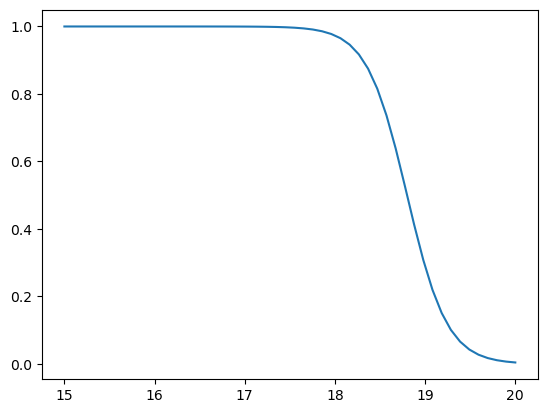

In [17]:
m = np.linspace(15,20,50)
m0=18.8
s=4.5
p = np.power(1. + np.exp((m - m0)*s), -1)
plt.plot(m,p)

In [18]:
# implement the the above selection function

def spec_selection_func(flux,m0=18.8,s=4.5):
    m = flux2mag(np.max(flux))
    p = np.power(1. + np.exp((m - m0)*s), -1)
    p0 = np.random.uniform(0,1)
    if p0 < p:
        return {"pass_spec_selection":True}
    else:
        return {"pass_spec_selection":False}

pass_selection = lightcurves_after_detection.reduce(spec_selection_func,"lightcurve.flux")
idx = pass_selection.query("pass_spec_selection == True").index
lightcurves_after_spec_selection = lightcurves_after_detection.loc[idx]
print("After spectroscopic selection: nsn=", len(lightcurves_after_spec_selection))

lightcurves["pass_spec_selection"] = False
lightcurves.loc[idx,"pass_spec_selection"] = True

After spectroscopic selection: nsn= 3481


/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:420: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().__setitem__(key, value)


In [19]:
## ZTF SN DR2 selection cuts
# Start 3795
# No ZTF light curve -17 = 3778
# No spectra -110 = 3668
# No confirmed Ia type from spectra -40 = 3628
# Good sampling (7 different phases, 2 before, 2 after peak, 2 bands) = 2960, peak based on a salt2 fit
# SALT2 cuts = 2667

#### ZTF SN DR2 selection cuts
<img src="figs/ztf_selection_Table1_Rigault2024.png" width="800" height="400">

In [20]:
def quality_cuts(flux,mjd,filter,n_phases=7, n_before_peak=2, n_after_peak=2, n_bands=2):
    peak_idx = np.argmax(flux)
    pass_cut = len(np.unique(np.floor(mjd))) >= n_phases
    pass_cut &= (peak_idx >= n_before_peak - 1) & (len(flux) - peak_idx >= n_after_peak - 1)
    pass_cut &= len(np.unique(filter)) >= n_bands
    return {"pass_quality_cuts": pass_cut}

In [21]:
pass_quality_cut = lightcurves_after_spec_selection.reduce(quality_cuts,"lightcurve.flux",
                                                           "lightcurve.mjd","lightcurve.filter")
idx = pass_quality_cut.query("pass_quality_cuts == True").index
lightcurves_after_quality_cut = lightcurves_after_spec_selection.loc[idx]
print("After quality cuts: nsn=", len(lightcurves_after_quality_cut))

lightcurves["pass_quality_cuts"] = False
lightcurves.loc[idx,"pass_quality_cuts"] = True

After quality cuts: nsn= 2693


/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:420: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().__setitem__(key, value)


In [22]:
lightcurves.head()

id          ra        dec  nobs            t0         z  \
0   0  199.481034  41.838571  1105  59074.599915  0.156601   
1   1   59.985667 -15.129433   657  58487.141962  0.136212   
2   2  355.108559 -23.011061   281  58491.445278  0.183541   
3   3  199.699635  21.748234    57  58796.641552  0.186285   
4   4  348.991442  78.269723   662  58552.781052  0.133693   

                                              params  \
0  {'radec.ra': 199.48144850677525, 'radec.dec': ...   
1  {'radec.ra': 59.985084071131986, 'radec.dec': ...   
2  {'radec.ra': 355.1086375436791, 'radec.dec': -...   
3  {'radec.ra': 199.69966008181706, 'radec.dec': ...   
4  {'radec.ra': 348.9915554669472, 'radec.dec': 7...   

                                          lightcurve  pass_spec_selection  \
0  [{mjd: 58288.222656, filter: 'g', flux: -2528....                False   
1  [{mjd: 58335.5, filter: 'g', flux: -452.064582...                False   
2  [{mjd: 58304.480469, filter: 'g', flux: 2719.3...                False   
3  [{mjd: 58449.519531, filter: 'r', flux: 4013.1...                False   
4  [{mjd: 58288.410156, filter: 'g', flux: 2628.4...                False   

   pass_quality_cuts  
0              False  
1              False  
2              False  
3              False  
4              False

In [23]:
#saving to parquet file
lightcurves.to_parquet("results/lightcurves.parquet")

In [24]:
res = fit_single_lc(lightcurves_after_quality_cut.iloc[0])
res

2025-10-01 10:20:02,020 - INFO - fitting 13, z=0.07793757740316264, mwebv=0.043882952143770755.


success              1.0
ncall              102.0
                   ...  
mwebv_mwebv_cov      0.0
id                  13.0
Length: 53, dtype: float64

In [25]:
lc_to_fit = lightcurves_after_quality_cut.iloc[0:]

In [26]:
# %%time
# result_df0 = lc_to_fit.apply(fit_single_lc,axis=1)

In [27]:
%%time
results = Parallel(n_jobs=10)(delayed(fit_single_lc)(row) for _index, row in lc_to_fit.iterrows())
result_df = pd.DataFrame(results)

/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/sncosmo/models.py:813: RuntimeWarning: overflow encountered in power
  10. ** (-0.4 * self._colorlaw(wave) * self._parameters[2]))
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/sncosmo/models.py:812: RuntimeWarning: invalid value encountered in multiply
  return (self._parameters[0] * (m0 + self._parameters[1] * m1) *
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/sncosmo/fitting.py:61: RuntimeWarning: invalid value encountered in dot
  phot_chisq = np.dot(np.dot(diff, invcov), diff)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/sncosmo/fitting.py:61: RuntimeWarning: overflow encountered in dot
  phot_chisq = np.dot(np.dot(diff, invcov), diff)


CPU times: user 2.96 s, sys: 525 ms, total: 3.48 s
Wall time: 30.4 s


In [28]:
result_df = result_df.set_index('id')

In [29]:
result_df.dropna()

,success,ncall,chisq,ndof,z,z_err,t0,t0_err,x0,x0_err,...,c_x0_cov,c_x1_cov,c_c_cov,c_mwebv_cov,mwebv_z_cov,mwebv_t0_cov,mwebv_x0_cov,mwebv_x1_cov,mwebv_c_cov,mwebv_mwebv_cov
id,,,,,,,,,,,,,,,,,,,,,
13.0,1.0,102.0,30.977984,22.0,0.077938,0.0,58448.672824,0.092773,0.000767,0.000011,...,-1.132798e-07,-0.000014,0.000175,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38.0,1.0,124.0,57.644441,66.0,0.056093,0.0,58349.414184,0.060011,0.000544,0.000006,...,-4.764061e-08,0.000068,0.000083,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128696.0,1.0,113.0,93.288810,91.0,0.087357,0.0,58780.334137,0.047346,0.000653,0.000004,...,-1.587754e-08,0.000105,0.000036,0.0,0.0,0.0,0.0,0.0,0.0,0.0
128763.0,1.0,111.0,12.137841,11.0,0.098025,0.0,58477.403973,0.348510,0.000278,0.000012,...,-3.696219e-07,0.006796,0.001383,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
result_df.to_csv('results/salt3fit_results.csv')